In [ ]:
# The code below produces a plot of the Continuous Hahn Poisson flow as described in the paper:
# "Visualising the flows of orthogonal polynomial expansions of the Riemann Xi-function".
# The program reads the file with pre-computed coefficients and produces an implicit plot, 
# i.e. it visualises the flow of the real roots when r varies. 
# Version 1.0, December 12, 2025. 

In [387]:
%%gp
default(realprecision, 300)
Phi(u) = 2*sum(n=1, 12, (2*Pi^2*n^4*exp(9*u/2)-3*Pi*n^2*exp(5*u/2))*exp(-Pi*n^2*exp(2*u)))
integr(x,n,a,b)=tanh(x/2)^n / cosh(x/2)^(2*a) * Phi(x) * hypergeom([a + n/2,a + n/2 + 1/2], [a+b+n+1/2],tanh(x/2)^2)
tes(n,a,b) = 2^(n+1) * gamma(2*a + 2*b + n - 1) / gamma(2*a + 2*b + 2*n - 1) * intnum(x= 0, 15, integr(x,n,a,b),2)
for(n=249,300, printf("%1.120e \n", tes(2*n,1,1));print("0"))


(u)->2*sum(n=1,12,(2*Pi^2*n^4*exp(9*u/2)-3*Pi*n^2*exp(5*u/2))*exp(-Pi*n^2*exp(2*u)))
(x,n,a,b)->tanh(x/2)^n/cosh(x/2)^(2*a)*Phi(x)*hypergeom([a+n/2,a+n/2+1/2],[a+b+n+1/2],tanh(x/2)^2)
(n,a,b)->2^(n+1)*gamma(2*a+2*b+n-1)/gamma(2*a+2*b+2*n-1)*intnum(x=0,15,integr(x,n,a,b),2)
1.253944626088616019782753194289917941728673156145783145491186981495227898138735584052119407675297907642021236984827954362 e-1360 
0
9.187790447471785912413226202732932794045438700204565584810483715126916650781347550783753769184992971162081496100057653177 e-1367 
0
6.687755114459358919915286085044638332802547949600872007919020914859074818088721108319032908944438556489120265841344251925 e-1373 
0
4.836120194108384989299326221992592269518008360237626521606899150222582343334840583600306086099410782899962227359552378228 e-1379 
0
3.474337902450093912502070341038343895849799389327519631527170551650319917163898139910907876481105582540166816156707582751 e-1385 
0
2.4797961705417973303500591431685370717517964760402129212520

In [264]:
#Continuous Hahn coefficients precomputation a,b,a,b for f(x) = Xi(x)
DRF=RealBallField(500)
CCF=ComplexBallField(500)

def Phi(x):
    termexp2x=-1*DRF(pi)*DRF(2*x).exp()
    termexp5x= 6*DRF(pi)*DRF(5*x/2).exp()
    termexp9x= 4*DRF(pi)*DRF(pi)*DRF(9*x/2).exp()
    sum=(DRF(0))
    for n in range(30):
        summand =  ((n+1)^4*termexp9x-(n+1)^2*termexp5x)*((n+1)^2*termexp2x).exp()   
        sum = sum + summand
    return sum

def hyp(n, a, b, x):
    p1 = CCF(a) + CCF(n / 2)
    p2 = CCF(a) + CCF(n / 2) + CCF("0.5") 
    q1 = CCF(a + b) + CCF(n) + CCF("0.5")
    z = (CCF(x / 2).tanh()).pow(2)
    hyp=z.hypergeometric([p1, p2], [q1])
    return hyp

def integrand(n, a, b, x):
    term1 = (CCF(x / 2).tanh()).pow(n) / ((x/2).cosh()).pow(2 * a)
    integr = term1 * Phi(x.abs()) * hyp(n, a, b, x)
    return integr

def CHcoeff(n, a, b, M):
    pre1 = CCF(2).pow(n) * CCF(2 * a + 2 * b + n - 1).gamma() / CCF(2*a + 2*b + 2*n - 1).gamma()
    res = 2 * pre1 * CCF.integral(lambda y, _: integrand(n, a, b, y), CCF(0), CCF(M))
    return real_part(res)

def GenCHcoeffs(a, b, N, M):
    f = open("ContHahnCoeffa1d2b1New", "w")
    for n in range(N):
        f.write(str(CHcoeff(2*n,CCF(a),CCF(b),M).mid()));f.write("\r\n")
        f.write(str("0"));f.write("\r\n")
    f.close() 
    return 0

#enter respectively a, b, number of coefficients desired (<500), integral limit) 
GenCHcoeffs(CCF("0.5"), CCF("1"), 8, 20)

0.495692692624699201120511504302382336530474791333656649326595214661055185315837896274529994707531929059997957095266139734834726381103980904267246668546
0
0.00113336329401615118486390884492623613646271824835416270090413965541567908233846464349377633302137209906089311227464923847302926988961910130916327325392
0
9.51527958555907839195121412595460100872996817350486655738233140874052952621529295853579519067748801022157528844495682749514766992818717924887827404260e-7
0
4.61462633281436635861568715301627123954702525549521100309154939358084304244874113179510825074398026516046245181757276221371484657215298884907675291391e-10
0
1.52409562695676698398108418778703326194460020433223245947556626356354540026778759544808343778513284672866964561962971463362547287536323748428229513136e-13
0
3.73750988231766542866606200234335816304096409558766718030967341235391944072426224263287281848755252117418923273240398144015995015808574479119732577356e-17
0
7.1801274677819296525118100185513993157690311134135001944

0

Automated checks:
The sum of all the coefficients is   : 0.5087310387263240 = Xi(ai) = 0.5087310387263240 (should be equal).
d/dr z_3(0) via Newton approximation : -661.184829 versus formula: -659.859461 (should be equal).
Ensure 20 digits accuracy at t = 60  : 0.00000000000000000000 (should show 20 zeros).


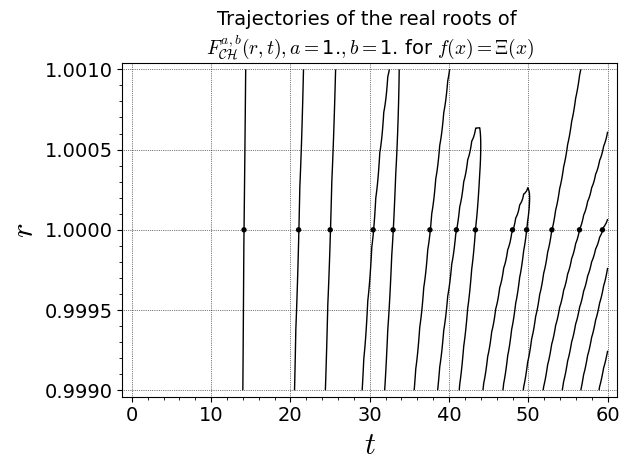

In [391]:
#Continuous Hahn for flow of Xi.
var("r","t");

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1500)
RDF=RealBallField(1500)

#Select the desired parametes a and b here and ensure the correct coefficient file is loaded
global a, b
a = CCF("1")
b = CCF("1")

ast = str(a.mid()); astr = ast.rstrip('0')
bst = str(b.mid()); bstr = bst.rstrip('0')

global m1; m1 = []; CoeffSum = RDF(0)
with open("ContHahnCoeffa1b1New", "r") as f:
    n = 0
    for row in f:
        CoeffSum = CoeffSum + CCF(-1).pow(n)*(2*a + n).gamma() * (a + b + n).gamma()  / ((2*a).gamma() * (a + b).gamma() * (n + 1).gamma()) * RDF(row)
        n = n + 1
        m1.append([RDF(row)])

def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def ContHahnPoly(t, n):
    pre = CCF(0,1).pow(n) * (2*a + n).gamma() * (a + b + n).gamma()  / ((2*a).gamma() * (a + b).gamma() * (n + 1).gamma())
    f1  = n  + 2*a + 2*b - 1; f2 = CCF(a,0)+I*CCF(t)
    CHpol = pre * CCF(1).hypergeometric([-n, f1, f2],[a + a, a + b])
    return CHpol

def ContHahnFlow(t,rho):
    sum=CCF(0)
    for n in range(300):
        kappa = CCF(2 * n + 2 * a + 2 * b - 1)
        #g = CCF(-kaprho).exp()
        g =CCF(rho)
        sum=sum+g.pow(2*n*kappa)*CCF(str(m1[2*n]))*ContHahnPoly(t, 2*n) * CCF(-1).pow(n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = RDF(ContHahnFlow(x0 + tr*100,1+tr) - ContHahnFlow(x0,1+tr)) / (tr*100)
        h = RDF(ContHahnFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr

def B(x):
    return (a.mid()-I*x)*(b.mid()-I*x)

def D(x):
    return (a.mid()+I*x)*(b.mid()+I*x)

#sum zeros around k-th zero
def prodzeros(k,c):
    zk =ordrho[k-1]
    prod0 = 1
    for j in range(k-1):
        prod0 = prod0 * (1 + c/(zk-ordrho[j]))*(1 + c/(zk+ordrho[j]))
    prod1 = 1
    for j in range(k+1,100001):
        prod1 = prod1 * (1 + c/(zk-ordrho[j-1]))*(1 + c/(zk+ordrho[j-1]))
    prod2 = (1 + c/(zk + zk))
    return c * prod0 * prod1 * prod2       

#compute d/dr zk via formula
def verifyDDE(k):
    return B(ordrho[k-1])*prodzeros(k,I) + D(ordrho[k-1])*prodzeros(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xi(ai) = %3.16f (should be equal)." % (CoeffSum, ContHahnFlow(CCF(0,a),1)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),real_part(verifyDDE(3))))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(ContHahnFlow(100,1)-Xi(100).mid()))

a1=implicit_plot(lambda t,r:RDF(ContHahnFlow(t,r)),(t,0,60),(r,0.999,1.001),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title=f'Trajectories of the real roots of \n'  + r'$F^{a,b}_{\mathcal{CH}}(r,t), a=$' + astr + r'$, b=$'+ bstr +' for $f(x)=\Xi(x)$',gridlines=True,plot_points=120)
show(a1 + z,aspect_ratio='automatic')

Automated checks:
The sum of all the coefficients is   : 52259294173955870658820797272604803072.0000000000000000 = Xi(ai) = 52259294173955870658820797272604803072.0000000000000000 (should be equal).
d/dr z_3(0) via Newton approximation : 18049.720595 versus formula: 18046.437650 (should be equal).
Ensure 20 digits accuracy at t = 60  : 0.00000000000000000000 (should show 20 zeros).


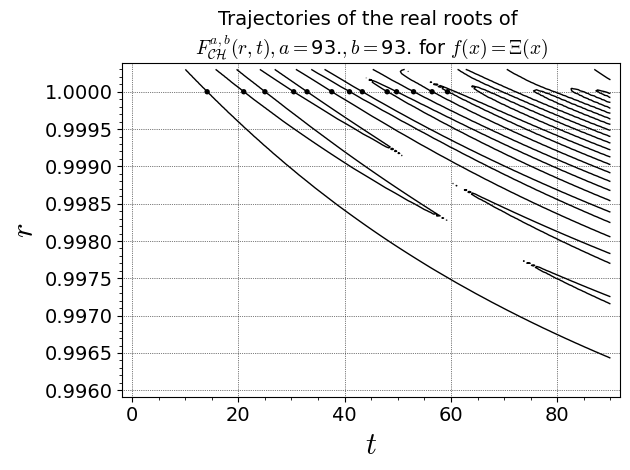

In [367]:
#Continuous Hahn for flow of Xi.
var("r","t");

#Generate a plot of all ordinates of the non-trivial zeros < 60 to overlay the flow graphs
var('y')
global ord, ordrho; ord = []; ordrho = []
with open("ordinateszetazeros.txt", "r") as f: #file is stored on GitHub
    for row in f:
        y=float(row)
        if y < 60:
            ord.append([y,1])
        ordrho.append(y)
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1500)
RDF=RealBallField(1500)

#Select the desired parametes a and b here and ensure the correct coefficient file is loaded
global a, b
a = CCF("93")
b = CCF("93")

ast = str(a.mid()); astr = ast.rstrip('0')
bst = str(b.mid()); bstr = bst.rstrip('0')

global m1; m1 = []; CoeffSum = RDF(0)
with open("ContHahnCoeffa93b93New", "r") as f:
    n = 0
    for row in f:
        CoeffSum = CoeffSum + CCF(-1).pow(n)*(2*a + n).gamma() * (a + b + n).gamma()  / ((2*a).gamma() * (a + b).gamma() * (n + 1).gamma()) * RDF(row)
        n = n + 1
        m1.append([RDF(row)])

def Xi(t):
    f=CCF("0.5",0)+I*CCF(t)
    xi=f/2*(f-1)*CCF(pi).pow(-f/2)*(f/2).gamma()*f.zeta()
    return xi

def ContHahnPoly(t, n):
    pre = CCF(0,1).pow(n) * (2*a + n).gamma() * (a + b + n).gamma()  / ((2*a).gamma() * (a + b).gamma() * (n + 1).gamma())
    f1  = n  + 2*a + 2*b - 1; f2 = CCF(a,0)+I*CCF(t)
    CHpol = pre * CCF(1).hypergeometric([-n, f1, f2],[a + a, a + b])
    return CHpol

def ContHahnFlow(t,rho):
    sum=CCF(0)
    for n in range(300):
        kappa = CCF(2 * n + 2 * a + 2 * b - 1)
        #g = CCF(-kaprho).exp()
        g =CCF(rho)
        sum=sum+g.pow(2*n*kappa)*CCF(str(m1[2*n]))*ContHahnPoly(t, 2*n) * CCF(-1).pow(n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = RDF(ordrho[k-1]);
    while(y):
        hd = RDF(ContHahnFlow(x0 + tr*100,1+tr) - ContHahnFlow(x0,1+tr)) / (tr*100)
        h = RDF(ContHahnFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -(x1 - RDF(ordrho[k-1]))/(tr) 
    return dzdr

def B(x):
    return (a.mid()-I*x)*(b.mid()-I*x)

def D(x):
    return (a.mid()+I*x)*(b.mid()+I*x)

#sum zeros around k-th zero
def prodzeros(k,c):
    zk =ordrho[k-1]
    prod0 = 1
    for j in range(k-1):
        prod0 = prod0 * (1 + c/(zk-ordrho[j]))*(1 + c/(zk+ordrho[j]))
    prod1 = 1
    for j in range(k+1,400001):
        prod1 = prod1 * (1 + c/(zk-ordrho[j-1]))*(1 + c/(zk+ordrho[j-1]))
    prod2 = (1 + c/(zk + zk))
    return c * prod0 * prod1 * prod2       

#compute d/dr zk via formula
def verifyDDE(k):
    return B(ordrho[k-1])*prodzeros(k,I) + D(ordrho[k-1])*prodzeros(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xi(ai) = %3.16f (should be equal)." % (CoeffSum, ContHahnFlow(CCF(0,a),1)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),real_part(verifyDDE(3))))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(ContHahnFlow(100,1)-Xi(100).mid()))

a1=implicit_plot(lambda t,r:RDF(ContHahnFlow(t,r)),(t,0,60),(r,0.996,1.0003),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title=f'Trajectories of the real roots of \n'  + r'$F^{a,b}_{\mathcal{CH}}(r,t), a=$' + astr + r'$, b=$'+ bstr +' for $f(x)=\Xi(x)$',gridlines=True,plot_points=150)
show(a1 + z,aspect_ratio='automatic')

Automated checks:
The sum of all the coefficients is   : 2488827997866001087493765595136.0000000000000000 = Xin(ai) = 2488827997866001087493765595136.0000000000000000 (should be equal).
d/dr z_3(0) via Newton approximation : 14195.701441 versus formula: 14195.701791 (should be equal).
Ensure 20 digits accuracy at t = 60  : -0.00000000000000000000 (should show 20 zeros).


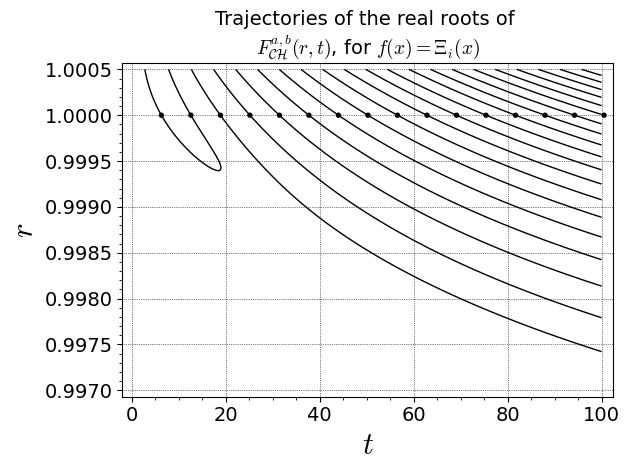

In [376]:
#Continuous Hahn for flow of Xi_i.
var("r","t");

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y')
ord = []
for y in range(16):
    ord.append([2*pi()*(y+1),1])
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Select the desired parametes a and b here
global a, b
a = CCF("150")
b = CCF("150")

ast = str(a.mid()); astr = ast.rstrip('0')
bst = str(b.mid()); bstr = bst.rstrip('0')

# Generate and store the coefficients for a and b

def hyp(n, x):
    p1 = CCF(b) + CCF(n / 2)
    p2 = CCF(b) + CCF(n / 2) + CCF("0.5") 
    q1 = CCF(a + b + n) + CCF("0.5")
    z = CCF(x).pow(2)
    hyp=z.hypergeometric([p1, p2], [q1])
    return hyp

def integrand(n, x):
    term1 = CCF(x).pow(n) * CCF(1 -  x.pow(2)).pow(b - 1)
    integr = term1 * hyp(n, x)
    return integr

def CHcoeff(n):
    pre = CCF(2).pow(n + 2) * CCF(2 * a + 2 * b + n - 1).gamma() / CCF(2*a + 2 * b + 2 * n - 1).gamma()
    res =  pre * CCF.integral(lambda y, _: integrand(n, y), CCF(0), CCF("0.25").tanh())
    return real_part(res)

global m1; m1 = [];
CoeffSum = CCF("0")
for n in range(501):
    if n % 2:
        Coe = CCF("0") 
    else:
        Coe = CHcoeff(n)
    CoeffSum = CoeffSum + CCF(-1).pow(n)*(2*a + n).gamma() * (a + b + n).gamma()  / ((2*a).gamma() * (a + b).gamma() * (n + 1).gamma()) * Coe
    m1.append([Coe])

# Make the plot based on the coefficients for a and b

def Xin(t):
    Xin=2*CCF(t/2).sin()/CCF(t)
    return Xin

def ContHahnPoly(t, n):
    pre = CCF(0,1).pow(n) * (2*a + n).gamma() * (a + b + n).gamma()  / ((2*a).gamma() * (a + b).gamma() * (n + 1).gamma())
    f1  = n  + 2*a + 2*b - 1; f2 = CCF(a,0)+I*CCF(t)
    CHpol = pre * CCF(1).hypergeometric([-n, f1, f2],[a + a, a + b])
    return CHpol

def ContHahnFlow(t,rho):
    sum=CCF(0)
    for n in range(250):
        kappa = CCF(2 * n + 2 * a + 2 * b - 1)
        #g = CCF(-kaprho).exp()
        g = CCF(rho)
        sum=sum+g.pow(2*n*kappa)*CCF(str(m1[2*n]))*ContHahnPoly(t, 2*n) * CCF(-1).pow(n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = RDF(ContHahnFlow(x0 + tr*100,1+tr) - ContHahnFlow(x0,1+tr)) / (tr*100)
        h = RDF(ContHahnFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr

def B(x):
    return (a.mid()-I*x)*(b.mid()-I*x)

def D(x):
    return (a.mid()+I*x)*(b.mid()+I*x)

#closed form for sum of zeros around k-th zero
def ZS(k,z):
    zk =(2*pi()*k)
    return 2*zk*sin(z/2)/(zk + z)   

#compute d/dr zk via formula
def verifyDDE(k):
    return B(2 * pi() * k) * ZS(k,I) + D(2 * pi() * k) * ZS(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xin(ai) = %3.16f (should be equal)." % (CoeffSum.mid(), ContHahnFlow(CCF(0,a),1)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),real_part(verifyDDE(3))))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(ContHahnFlow(100,1)-Xin(100).mid()))

#a150i=implicit_plot(lambda t,r:RDF(ContHahnFlow(t,r)),(t,0,150),(r,0.994,1.0005),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title=f'Trajectories of the real roots of \n'  + r'$F^{a,b}_{\mathcal{CH}}(r,t), a=$' + astr + r'$, b=$'+ bstr +' for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=120)
a150i=implicit_plot(lambda t,r:RDF(ContHahnFlow(t,r)),(t,0,100),(r,0.997,1.0005),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title=f'Trajectories of the real roots of \n'  + r'$F^{a,b}_{\mathcal{CH}}(r,t)$, for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=210)
show(a150i + z,aspect_ratio='automatic')

Automated checks:
The sum of all the coefficients is   : 134405857090806767318154084772649096970240.0000000000000000 = Xin(ai) = 134405857090806767318154084772649096970240.0000000000000000 (should be equal).
d/dr z_3(0) via Newton approximation : 20043.356585 versus formula: 20043.357257 (should be equal).
Ensure 20 digits accuracy at t = 60  : 0.00000000000000000000 (should show 20 zeros).


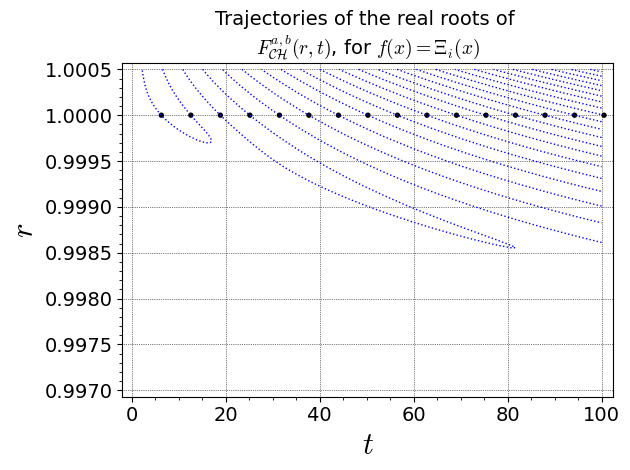

In [377]:
#Continuous Hahn for flow of Xi_i.
var("r","t");

#Generate a plot of all ordinates of the zeros < 60 to overlay the flow graphs
var('y')
ord = []
for y in range(16):
    ord.append([2*pi()*(y+1),1])
z=list_plot(ord, size=15, marker="o", color = "black")

CCF=ComplexBallField(1024)
RDF=RealBallField(1024)

#Select the desired parametes a and b here
global a, b
a = CCF("200")
b = CCF("200")

ast = str(a.mid()); astr = ast.rstrip('0')
bst = str(b.mid()); bstr = bst.rstrip('0')

# Generate and store the coefficients for a and b

def hyp(n, x):
    p1 = CCF(b) + CCF(n / 2)
    p2 = CCF(b) + CCF(n / 2) + CCF("0.5") 
    q1 = CCF(a + b + n) + CCF("0.5")
    z = CCF(x).pow(2)
    hyp=z.hypergeometric([p1, p2], [q1])
    return hyp

def integrand(n, x):
    term1 = CCF(x).pow(n) * CCF(1 -  x.pow(2)).pow(b - 1)
    integr = term1 * hyp(n, x)
    return integr

def CHcoeff(n):
    pre = CCF(2).pow(n + 2) * CCF(2 * a + 2 * b + n - 1).gamma() / CCF(2*a + 2 * b + 2 * n - 1).gamma()
    res =  pre * CCF.integral(lambda y, _: integrand(n, y), CCF(0), CCF("0.25").tanh())
    return real_part(res)

global m1; m1 = [];
CoeffSum = CCF("0")
for n in range(501):
    if n % 2:
        Coe = CCF("0") 
    else:
        Coe = CHcoeff(n)
    CoeffSum = CoeffSum + CCF(-1).pow(n)*(2*a + n).gamma() * (a + b + n).gamma()  / ((2*a).gamma() * (a + b).gamma() * (n + 1).gamma()) * Coe
    m1.append([Coe])

# Make the plot based on the coefficients for a and b

def Xin(t):
    Xin=2*CCF(t/2).sin()/CCF(t)
    return Xin

def ContHahnPoly(t, n):
    pre = CCF(0,1).pow(n) * (2*a + n).gamma() * (a + b + n).gamma()  / ((2*a).gamma() * (a + b).gamma() * (n + 1).gamma())
    f1  = n  + 2*a + 2*b - 1; f2 = CCF(a,0)+I*CCF(t)
    CHpol = pre * CCF(1).hypergeometric([-n, f1, f2],[a + a, a + b])
    return CHpol

def ContHahnFlow(t,rho):
    sum=CCF(0)
    for n in range(250):
        kappa = CCF(2 * n + 2 * a + 2 * b - 1)
        #g = CCF(-kaprho).exp()
        g = CCF(rho)
        sum=sum+g.pow(2*n*kappa)*CCF(str(m1[2*n]))*ContHahnPoly(t, 2*n) * CCF(-1).pow(n)
    return real_part(sum.mid())

#compute d/dr zk Newton approximation
def dzdrzk(k):
    tr = RDF("0.0000000001");x0 = 2*k*RDF.pi();
    while(y):
        hd = RDF(ContHahnFlow(x0 + tr*100,1+tr) - ContHahnFlow(x0,1+tr)) / (tr*100)
        h = RDF(ContHahnFlow(x0,1+tr))/hd ;x1 = x0 - h;ab = h.abs();x0 = x1
        if ab < tr:
            break
    dzdr = -(x1 - 2*k*RDF.pi())/(tr) 
    return dzdr

def B(x):
    return (a.mid()-I*x)*(b.mid()-I*x)

def D(x):
    return (a.mid()+I*x)*(b.mid()+I*x)

#closed form for sum of zeros around k-th zero
def ZS(k,z):
    zk =(2*pi()*k)
    return 2*zk*sin(z/2)/(zk + z)   

#compute d/dr zk via formula
def verifyDDE(k):
    return B(2 * pi() * k) * ZS(k,I) + D(2 * pi() * k) * ZS(k,-I)

print("Automated checks:")
print("The sum of all the coefficients is   : %3.16f = Xin(ai) = %3.16f (should be equal)." % (CoeffSum.mid(), ContHahnFlow(CCF(0,a),1)))
print("d/dr z_3(0) via Newton approximation : %3.6f versus formula: %3.6f (should be equal)." % (dzdrzk(3),real_part(verifyDDE(3))))
print("Ensure 20 digits accuracy at t = 60  : %3.20f (should show 20 zeros)." % real_part(ContHahnFlow(100,1)-Xin(100).mid()))

#a1i=implicit_plot(lambda t,r:RDF(ContHahnFlow(t,r)),(t,0,150),(r,0.994,1.0005),color='black',fontsize=14,linestyle ="-",linewidth=1,axes_labels=['$t$',r'$r$'],title=f'Trajectories of the real roots of \n'  + r'$F^{a,b}_{\mathcal{CH}}(r,t), a=$' + astr + r'$, b=$'+ bstr +' for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=120)
a200i=implicit_plot(lambda t,r:RDF(ContHahnFlow(t,r)),(t,0,100),(r,0.997,1.0005),color='blue',fontsize=14,linestyle =":",linewidth=1,axes_labels=['$t$',r'$r$'],title=f'Trajectories of the real roots of \n'  + r'$F^{a,b}_{\mathcal{CH}}(r,t)$, for $f(x)=\Xi_i(x)$',gridlines=True,plot_points=210)
show(a200i + z,aspect_ratio='automatic')

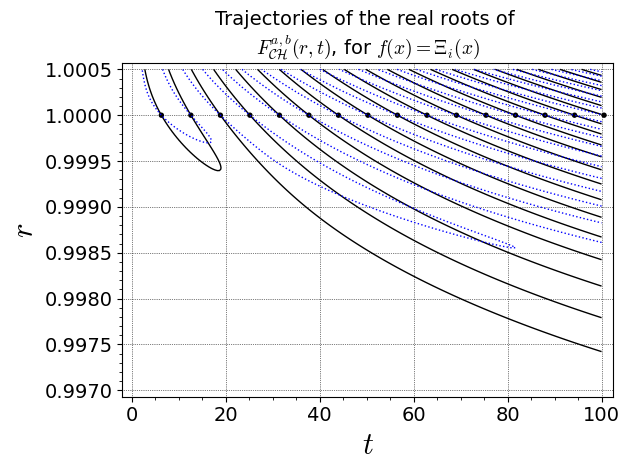

In [378]:
show(a150i + a200i + z,aspect_ratio='automatic')